In [1]:
import numpy as np
import pandas as pd
import random
# load et simulation function from simulate_population.py: 
from simulate_population import sim_population
import torch
import torch.nn as nn

## 0) Simulate the data and test set (df_short and df_test)

In [4]:
# simulate data 
horizon = 10
pop = sim_population(N=20000, step_forward=horizon, randomseed=42+7)
df_short = pop.history[0].copy()
events = ["a", "b", "c", "d", "e"]
for e in events:
    df_short[f"time_{e}"] = df_short[f"time_{e}"].fillna(horizon)
    df_short[f"time_{e}"] = np.minimum(horizon, df_short[f"time_{e}"].fillna(horizon))

In [9]:
# simulate test data
pop_test = sim_population(N=5000, step_forward=horizon, randomseed=42+100+7)
df_test = pop_test.history[0].copy()
for e in events:
    df_test[f"time_{e}"] = df_test[f"time_{e}"].fillna(horizon)
    df_test[f"time_{e}"] = np.minimum(horizon, df_test[f"time_{e}"].fillna(horizon))

In [11]:
# concordance index calculations
from lifelines.utils import concordance_index
def get_cindex_for_event(predictions, df = df_short, event = "b"):
    time_col = f"time_{event}"
    risk_col = f"event_{event}"
    c = concordance_index(df[time_col], predictions, df[risk_col])
    return(c)

In [12]:
# X -> g(X, t, no time-varying covariates) -> g(X) * g0(t) <=> proportional hazards PH 
# time = age , but not a positional (same as in Delphi-2m), it is a context 
# binary outcomes t0 -> t1 , from age0 -> age1 
# batch should be stratified by outcome
# x-> FFW -> FFW -> fit a normal Cox Model to the embedding -> compute c-index -> update FFW weights ?
# This way we found embedding for the initial features, and fit a Cox model-> very transparent 
# multi-outcome: cause-specific Cox models for each variable 

# x → NN → single risk score -> minimize Cox loss


In [13]:
e = "a"
time_col = f"time_{e}"
event_col = f"event_{e}"

## Define classes

### CoxNN in pytorch

In [444]:
class CoxNN(nn.Module):
    def __init__(self, p, hidden_dims=(64, 32)):
        super().__init__()
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # scalar risk score
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)  # shape (n,)

# This is the same as 
#class CoxNN(nn.Module):
#    def __init__(self, p, hidden_dims = [64,32]):
#        super().__init__()
#        self.fc1 = nn.Linear(p, hidden_dims[0])
#        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#        self.out = nn.Linear(hidden_dims[1], 1)  # scalar risk score#
#    def forward(self, x):
#        x = self.fc1(x)
#        x = F.relu(x)#
#        x = self.fc2(x)
#        x = F.relu(x)
#        x = self.out(x)
#        return x.squeeze(-1)  # shape (n,)

In [446]:
### Cox PH partial log-likelihood
def cox_partial_loglik(eta, time, event):
    """ eta: (n,) risk scores;     time: (n,) observed times;     event: (n,) 1 if event, 0 if censored """
    # sort by decreasing time
    order = torch.argsort(time, descending=True)
    eta = eta[order]
    event = event[order]
    # log cumulative sum of exp(eta)
    log_cumsum_exp = torch.logcumsumexp(eta, dim=0)
    # 3. contribution only from observed events
    loglik = eta[event == 1] - log_cumsum_exp[event == 1]
    return -loglik.sum()

In [448]:
def train_cox(x, time, event, hidden_dims = (), epochs = 10):
    p = len(x[0])
    model = CoxNN(p=p, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   
    for epoch in range(epochs):
        optimizer.zero_grad()
        eta = model(x)                     # risk scores
        loss = cox_partial_loglik(eta, time, event)
        loss.backward()
        optimizer.step()
        if ((epoch % 200 == 0)|(epoch +1 == epochs)):
            print(f"Epoch {epoch}, loss = {loss.item():.4f}")
    return (model)

In [450]:
# prepare the data 
def prepare_data_for_cox(df, 
                         covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"], 
                         event_type = "a"):
    time_col = f"time_{event_type}"
    event_col = f"event_{event_type}"
    x = torch.tensor( df[covariate_cols].values, dtype=torch.float32)
    time = torch.tensor( df[time_col].values, dtype=torch.float32)
    event = torch.tensor(df[event_col].values, dtype=torch.float32)
    return (x, time, event)

### CoxPH in lifelines

In [453]:
from lifelines import CoxPHFitter

def simplecox(df, covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"], event_type = "a"):
    time_col = f"time_{event_type}"
    event_col = f"event_{event_type}"
    cph = CoxPHFitter()
    cph.fit(df_short[[time_col, event_col] + covariate_cols], duration_col= time_col, event_col=event_col)
    #s=cph.summary[['coef', 'se(coef)', 'p']]
    #beta_cox = cph.params_.values
    return (cph)

## Examples

In [456]:
covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
event_to_check= "b"

#### a) Example1 - CoxPH from Lifelines:

In [459]:
cph = simplecox(df_short, covariate_cols= covariate_cols, event_type = event_to_check)
round(cph.summary[['coef', 'se(coef)', 'p']],4)

,coef,se(coef),p
covariate,,,
age_start,0.0284,0.0006,0.0000
bmi,-0.0049,0.0106,0.6414
hyp,0.5853,0.0200,0.0000
smoke,-0.0321,0.0241,0.1826
sex,-0.0112,0.0169,0.5089
eth1,-0.0129,0.0190,0.4969
eth2,0.0309,0.0286,0.2785


#### b) Example2 - CoxNN with no layers

In [461]:
# Checking that this gives usual Cox estimates with hidden_dims ==0
# coxn0 = CoxNN(p=5, hidden_dims = ())

In [464]:
x, time, event = prepare_data_for_cox(df_short,covariate_cols=covariate_cols, event_type = event_to_check)
coxn0 = train_cox(x,time,event, hidden_dims= (), epochs = 4000)

Epoch 0, loss = 226810.2500
Epoch 200, loss = 155569.0781
Epoch 400, loss = 130572.3594
Epoch 600, loss = 129978.1641
Epoch 800, loss = 129942.7031
Epoch 1000, loss = 129933.3984
Epoch 1200, loss = 129931.5703
Epoch 1400, loss = 129931.3125
Epoch 1600, loss = 129931.2656
Epoch 1800, loss = 129931.2734
Epoch 2000, loss = 129931.2812
Epoch 2200, loss = 129931.2734
Epoch 2400, loss = 129931.2812
Epoch 2600, loss = 129931.2734
Epoch 2800, loss = 129931.2734
Epoch 3000, loss = 129931.2734
Epoch 3200, loss = 129931.2734
Epoch 3400, loss = 129931.2734
Epoch 3600, loss = 129931.2734
Epoch 3800, loss = 129931.2734
Epoch 3999, loss = 129931.2734


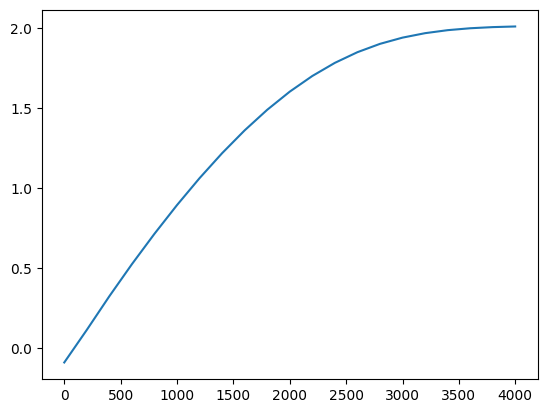

In [226]:
# learning the beta for eth2 == 2.00, or for eth1 == 0.50 (wouldnt work, but was before train_cox returned betas too
plt.plot(betas.index, betas.iloc[:,6])

In [289]:
# betas 
linear_layer = coxn0.net[0]
beta_nn = linear_layer.weight.detach().cpu().numpy().flatten()
bias_nn = linear_layer.bias.detach().cpu().numpy()
s["coef_CoxNN_1layer"] = beta_nn
s

,coef,se(coef),p,coef2,coef_CoxNN_1layer
covariate,,,,,
age_start,0.026313,0.000525,0.000000e+00,0.026312,0.026312
bmi,0.506781,0.008902,0.000000e+00,0.506771,0.506771
hyp,0.696061,0.019997,1.847556e-265,0.696033,0.696033
smoke,-0.026934,0.023678,2.553357e-01,-0.026936,-0.026936
sex,0.022082,0.016707,1.862397e-01,0.022082,0.022082
eth1,0.500646,0.018687,4.133464e-158,0.500602,0.500602
eth2,2.011789,0.027206,0.000000e+00,2.011612,2.011612


In [230]:
#After training:
#• eta = model(x) is the estimated log-risk
#• exp(eta) gives relative hazard
#• ordering of eta defines the risk ranking
#• no baseline hazard is estimated

#### b) Example2 - CoxNN with (16,16) layers

In [291]:
# Train a "real" CoxNN with hidden layers for encoding the covariates 
coxn = train_cox(x,time,event, hidden_dims= (16,16), epochs = 5000)

Epoch 0, loss = 135221.5156
Epoch 200, loss = 131310.0625
Epoch 400, loss = 130387.4844
Epoch 600, loss = 130387.0547
Epoch 800, loss = 130386.7734
Epoch 1000, loss = 130386.7188
Epoch 1200, loss = 130386.6797
Epoch 1400, loss = 130386.6797
Epoch 1600, loss = 130386.5000
Epoch 1800, loss = 130386.4375
Epoch 2000, loss = 130386.3281
Epoch 2200, loss = 130386.2969
Epoch 2400, loss = 130385.9688
Epoch 2600, loss = 130385.7891
Epoch 2800, loss = 130385.6172
Epoch 3000, loss = 130385.4375
Epoch 3200, loss = 130385.2812
Epoch 3400, loss = 130385.4688
Epoch 3600, loss = 130385.2812
Epoch 3800, loss = 130385.0156
Epoch 4000, loss = 130384.9375
Epoch 4200, loss = 130384.9531
Epoch 4400, loss = 130384.8438
Epoch 4600, loss = 130384.9062
Epoch 4800, loss = 130384.8750
Epoch 4999, loss = 130384.8125


### Comparison for CoxPH and CoxNN

In [292]:
# compute log-hazards from CoxPH 
risk1 = cph.predict_log_partial_hazard(df_test[covariate_cols])

In [293]:
# compute log-hazards from CoxNN
x_test = torch.tensor( df_test[covariate_cols].values, dtype=torch.float32)
risk2 = coxn0(x_test).detach().numpy() 

*--- Risk from CoxPH (x) and CoxNN_zero (y)---*


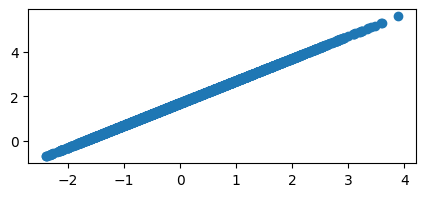

In [294]:
# plot one vs the other - should be the same 
import matplotlib.pyplot as plt
print ("*--- Risk from CoxPH (x) and CoxNN_zero (y)---*")
plt.figure(figsize = (5,2))
plt.scatter(risk1, risk2)

In [295]:
risk3 = coxn(x_test).detach().numpy() 

*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*


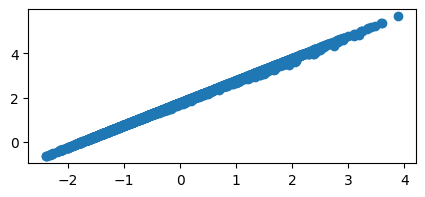

In [309]:
print ("*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*")
plt.figure(figsize = (5,2))
plt.scatter(risk1, risk3)

In [311]:
# compute c-index and betas from CoxPH and CoxNN
#  coxn0: 
# the model CoxNN with hidden_dim=() reduces to exactly one layer nn.Linear(p, 1)
#• weights of shape (1, p)
#• bias enabled by default
# That bias is the only deviation from a standard CoxPH.
#• beta_nn corresponds to the Cox coefficients
#• bias_nn should ideally be ~0 (but shouldn’t exist in Cox)
# --cindex 
c1 = get_cindex_for_event(risk1*(-1), df= df_test, event= e)
c2 = get_cindex_for_event(risk2*(-1), df= df_test, event= e)
c3 = get_cindex_for_event(risk3*(-1), df= df_test, event= e)
# betas 
linear_layer = coxn0.net[0]
beta_nn = linear_layer.weight.detach().cpu().numpy().flatten()
bias_nn = linear_layer.bias.detach().cpu().numpy()

In [313]:
# Display results - diff between training Cox Loss in NN and CoxPH in lifelines

[ 0.02631237  0.50677073  0.6960332  -0.02693595  0.02208215  0.50060153
  2.0116122 ]
[ 0.02631286  0.50678091  0.69606134 -0.02693378  0.02208243  0.50064559
  2.01178914]
C_index for df_test: [0.72303 0.72302 0.72296]


C:\Users\dinab\AppData\Local\Temp\ipykernel_25028\3378356929.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.723' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  np.round([c1, c2, c3],3)


,CoxPH,CoxNN_0,CoxNN_1
covariate,,,
age_start,0.026,0.026,NaN
bmi,0.507,0.507,NaN
hyp,0.696,0.696,NaN
smoke,-0.027,-0.027,NaN
sex,0.022,0.022,NaN
eth1,0.501,0.501,NaN
eth2,2.012,2.012,NaN
Cindex,0.723,0.723,0.723


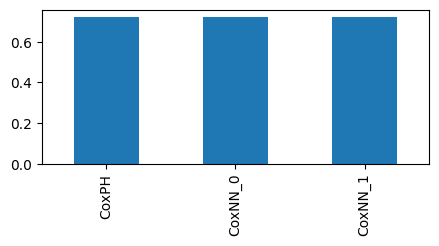

In [315]:
print(beta_nn)
print(beta_cox)
res = pd.DataFrame({"CoxPH" : cph.summary['coef']})
res["CoxNN_0"] = beta_nn
res["CoxNN_1"] = np.nan
res.loc["Cindex", :] =  np.round([c1, c2, c3],3)
res.loc["Cindex", :].plot.bar(figsize = (5,2))
print("C_index for df_test:", np.round([c1, c2, c3], 5))
np.round(res,3)

## All in one go: 
### train and validate CoxPH, CoxNN_0 (no layers, equivalent to CoxPH) and CoxNN_1 

In [600]:
def check_outcome (df_short, df_test,
                   covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"],
                   hidden_dims= (16,16), 
                   event_type = "a", 
                   epoch1 = 10, 
                   epoch2 = 10): #better 4000
    # 1 simple cox
    cph = simplecox(df_short, covariate_cols, event_type)
    beta1 = cph.summary['coef']
    pval = np.round(cph.summary['p'],5)
    
    # 2 null deep cox 
    x, time, event = prepare_data_for_cox(df_short,covariate_cols, event_type)
    coxnull = train_cox(x, time, event, hidden_dims = (), epochs = epoch1) 
    linear_layer = coxnull.net[0]
    beta2 = linear_layer.weight.detach().cpu().numpy().flatten()
    #bias_nn = linear_layer.bias.detach().cpu().numpy()
    
    # 3 real deep cox
    coxreal = train_cox(x, time, event, hidden_dims = hidden_dims, epochs = epoch2) 
    
    # --cindex 
    risk1 = cph.predict_log_partial_hazard(df_test[covariate_cols])
    risk2 = coxnull(x_test).detach().numpy() 
    risk3 = coxreal(x_test).detach().numpy() 
    c1 = get_cindex_for_event(risk1*(-1), df = df_test, event = event_type)
    c2 = get_cindex_for_event(risk2*(-1), df = df_test, event = event_type)
    c3 = get_cindex_for_event(risk3*(-1), df = df_test, event = event_type)
    
    # betas
    betas = pd.DataFrame({"event": event_type, "pval": pval, "CoxPH": beta1, "CoxNN_null": beta2, "CoxNN_real": np.nan})
    betas.index = cph.summary['coef'].index
    cind = np.array([c1, c2, c3], dtype=np.float32)
    
    models = [];  models.append(cph);     models.append(coxnull);     models.append(coxreal)
    
    return models, betas, cind 

In [498]:
# r1 = check_outcome(df_short, event_type="b"); r1[1]

In [602]:
# we will run the above function for each event one by one 
# store all the models (cox, coxm0 and coxnn in models for each event)
# models [outcome number 0-"a", ... 3-"e"][model number 0-coxph, 1-coxn0, 2-coxnn]
res = []; models = []; cinds = []
events = ["a", "b", "c", "d", "e"]
for e in events:
    print(e)
    model_e, res_e, cind_e = check_outcome (df_short,df_test, hidden_dims= (16,16), event_type = e,epoch1=4000, epoch2=5000)
    res.append(res_e);     models.append(model_e); cinds.append(cind_e)    
res = pd.concat(res, axis=0)
cinds = pd.DataFrame(cinds); cinds.index = events; cinds.columns = ["CoxPH","CoxNN_null","CoxNN_real"]

a
Epoch 0, loss = 225982.3906
Epoch 200, loss = 162632.0625
Epoch 400, loss = 132987.7969
Epoch 600, loss = 131936.2812
Epoch 800, loss = 131625.9688
Epoch 1000, loss = 131370.2969
Epoch 1200, loss = 131153.7656
Epoch 1400, loss = 130970.0312
Epoch 1600, loss = 130816.9062
Epoch 1800, loss = 130692.9219
Epoch 2000, loss = 130596.0312
Epoch 2200, loss = 130523.3984
Epoch 2400, loss = 130471.4922
Epoch 2600, loss = 130436.3359
Epoch 2800, loss = 130413.9375
Epoch 3000, loss = 130400.6406
Epoch 3200, loss = 130393.3359
Epoch 3400, loss = 130389.6406
Epoch 3600, loss = 130387.9453
Epoch 3800, loss = 130387.2578
Epoch 3999, loss = 130387.0000
Epoch 0, loss = 145957.6719
Epoch 200, loss = 131532.4062
Epoch 400, loss = 130411.0859
Epoch 600, loss = 130386.8125
Epoch 800, loss = 130386.0781
Epoch 1000, loss = 130385.6875
Epoch 1200, loss = 130385.4531
Epoch 1400, loss = 130385.2891
Epoch 1600, loss = 130385.1484
Epoch 1800, loss = 130385.0547
Epoch 2000, loss = 130384.9531
Epoch 2200, loss = 1

## Results

<Axes: >

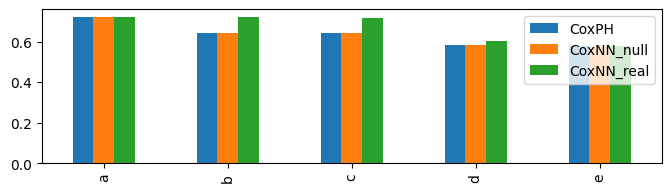

In [558]:
cinds.plot.bar(figsize = (8,2))

In [603]:
cinds

,CoxPH,CoxNN_null,CoxNN_real
a,0.723025,0.723026,0.722843
b,0.640725,0.640726,0.722173
c,0.641725,0.641725,0.718594
d,0.585915,0.585915,0.597777
e,0.580715,0.580716,0.569379


In [604]:
res

,event,pval,CoxPH,CoxNN_null,CoxNN_real
covariate,,,,,
age_start,a,0.00000,0.026313,0.026274,NaN
bmi,a,0.00000,0.506781,0.506017,NaN
hyp,a,0.00000,0.696061,0.694775,NaN
smoke,a,0.25534,-0.026934,-0.026885,NaN
sex,a,0.18624,0.022082,0.022035,NaN
eth1,a,0.00000,0.500646,0.497557,NaN
eth2,a,0.00000,2.011789,1.998820,NaN
age_start,b,0.00000,0.028392,0.028392,NaN
bmi,b,0.64138,-0.004937,-0.004934,NaN


## Multi-outcome CoxNN

In [560]:
#By default, nn.Linear(in_dim, K) includes a bias term (one per outcome).
#Just like in the single-outcome Cox case:
#the bias cancels out in the partial likelihood
#but it’s cleaner and more identifiable to remove it

# K - number of events (K outcomes)
class MultiCoxNN(nn.Module):
    def __init__(self, p, hidden_dims=(64, 32), K=5):
        super().__init__()
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, K,bias=False))  #  risk score for each of the K outcomes
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)  # shape (n,k)

*What it is*:
K independent cause-specific Cox models sharing all hidden layers and trained jointly; borrowing strength across outcomes.

*What it is not*: a competing-risks softmax model, a Fine–Gray model, a joint likelihood over mutually exclusive events.

In [570]:
# prepare the data for multi-outcome
covariate_cols = ["age_start", "bmi", "hyp","smoke", "sex", "eth1", "eth2"]
time_cols = ["time_a", "time_b", "time_c", "time_d","time_e"]
event_cols = ["event_a", "event_b", "event_c", "event_d","event_e"]
x2 = torch.tensor( df_short[covariate_cols].values, dtype=torch.float32)
time2 = torch.tensor( df_short[time_cols].values, dtype=torch.float32)
event2 = torch.tensor(df_short[event_cols].values, dtype=torch.float32)


In [573]:
def train_coxmulti(x2, time2, event2, hidden_dims = (), epochs = 4000, K=5):
    p = len(x2[0])
    # p -number of initial params, len(covariate_cols)
    model = MultiCoxNN(p=p, K=K, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)   
    for epoch in range(epochs):
        optimizer.zero_grad()
        eta2 = model(x)                     # risk scores
        loss = 0
        for k in range(K):
            loss += cox_partial_loglik(
            eta2[:, k],
            time2[:, k],
            event2[:, k])
        loss = loss / K
        loss.backward()
        optimizer.step()
        if ((epoch % 50 == 0)|(epoch +1 == epochs)):
            print(f"Epoch {epoch}, loss = {loss.item():.4f}")
    return (model)

### Train the multicox models, empty and actual one 

In [576]:
coxmmulti_null = train_coxmulti(x2, time2, event2, hidden_dims = ())

Epoch 0, loss = 106460.4219
Epoch 50, loss = 85742.6406
Epoch 100, loss = 85464.7969
Epoch 150, loss = 85401.3047
Epoch 200, loss = 85382.9531
Epoch 250, loss = 85378.8359
Epoch 300, loss = 85378.1797
Epoch 350, loss = 85378.1016
Epoch 400, loss = 85378.0938
Epoch 450, loss = 85378.0938
Epoch 500, loss = 85378.1016
Epoch 550, loss = 85378.1016
Epoch 600, loss = 85378.1016
Epoch 650, loss = 85378.1016
Epoch 700, loss = 85378.1016
Epoch 750, loss = 85378.0938
Epoch 800, loss = 85378.0938
Epoch 850, loss = 85378.0938
Epoch 900, loss = 85378.0938
Epoch 950, loss = 85378.0938
Epoch 1000, loss = 85378.0938
Epoch 1050, loss = 85378.0938
Epoch 1100, loss = 85378.0938
Epoch 1150, loss = 85378.0938
Epoch 1200, loss = 85378.0938
Epoch 1250, loss = 85378.0938
Epoch 1300, loss = 85378.0938
Epoch 1350, loss = 85378.0938
Epoch 1400, loss = 85378.0938
Epoch 1450, loss = 85378.0938
Epoch 1500, loss = 85378.0938
Epoch 1550, loss = 85378.1016
Epoch 1600, loss = 85378.1016
Epoch 1650, loss = 85378.1016
Ep

In [578]:
coxmmulti = train_coxmulti(x2, time2, event2, hidden_dims = (64,64))

Epoch 0, loss = 87390.6719
Epoch 50, loss = 85097.6250
Epoch 100, loss = 84517.9062
Epoch 150, loss = 84449.7031
Epoch 200, loss = 84359.8125
Epoch 250, loss = 84263.6875
Epoch 300, loss = 84204.8359
Epoch 350, loss = 84166.2188
Epoch 400, loss = 84159.3203
Epoch 450, loss = 84157.5000
Epoch 500, loss = 84148.6250
Epoch 550, loss = 84147.2656
Epoch 600, loss = 84164.4531
Epoch 650, loss = 84138.9062
Epoch 700, loss = 84137.1016
Epoch 750, loss = 84141.6250
Epoch 800, loss = 84134.2500
Epoch 850, loss = 84138.1719
Epoch 900, loss = 84131.8594
Epoch 950, loss = 84129.9297
Epoch 1000, loss = 84184.7266
Epoch 1050, loss = 84136.6250
Epoch 1100, loss = 84130.3906
Epoch 1150, loss = 84128.8594
Epoch 1200, loss = 84127.7109
Epoch 1250, loss = 84126.7969
Epoch 1300, loss = 84125.8125
Epoch 1350, loss = 84124.7578
Epoch 1400, loss = 84129.2266
Epoch 1450, loss = 84123.8281
Epoch 1500, loss = 84127.5781
Epoch 1550, loss = 84128.6953
Epoch 1600, loss = 84121.5781
Epoch 1650, loss = 84127.2656
Epo

In [341]:
coxmmulti_null(x)[0,:]

tensor([2.1417, 1.7490, 1.7633, 1.0479, 0.8522], grad_fn=<SelectBackward0>)

### Compare the models - multi with one event

In [639]:
## We will compare the cindex and correlation of the predictions for the df_test 

def corr_with_coxph(risk, risk_coxph):
    return np.corrcoef(risk, risk_coxph)[0, 1]

def evaluate_all_models_cindex(    models,    coxmmulti_null,    coxmmulti,  
                               df_test,    covariate_cols,    time_cols,    event_cols,    events):
    """
    models[outcome][model]:
        model 0 = CoxPH
        model 1 = CoxNN_00
        model 2 = CoxNN_(64,64)
    """
    x_test = torch.tensor(df_test[covariate_cols].values,dtype=torch.float32    )
    rows = []
    corr_rows=[]
    # evaluate multi-output models once
    with torch.no_grad():
        risk_multi_null = coxmmulti_null(x_test).numpy()
        risk_multi      = coxmmulti(x_test).numpy()

    for k, e in enumerate(events):
        time_col  = time_cols[k]
        event_col = event_cols[k]
        # ---- single-event models ----
        cph   = models[k][0]
        coxn0 = models[k][1]
        coxn  = models[k][2]
        risk_cph = cph.predict_log_partial_hazard(df_test[covariate_cols]).values
        with torch.no_grad():
            risk_coxn0 = coxn0(x_test).numpy().squeeze()
            risk_coxn  = coxn(x_test).numpy().squeeze()
        row = {
            "event": e,
            "CoxPH": get_cindex_for_event( -risk_cph, df_test, e),
            "CoxNull": get_cindex_for_event( -risk_coxn0, df_test, e),
            "CoxReal": get_cindex_for_event(-risk_coxn, df_test, e),
            "MultiCoxNull": get_cindex_for_event(-risk_multi_null[:, k], df_test, e),
            "MultiCoxReal": get_cindex_for_event(-risk_multi[:, k], df_test, e),
        }
        rows.append(row)
        # ---------- correlation w/ CoxPH ----------
        corr_rows.append({
            "event": e,
            "CoxPH": 1.0,  # self-correlation
            "CoxNull": corr_with_coxph( risk_coxn0, risk_cph           ),
            "CoxReal": corr_with_coxph(                risk_coxn, risk_cph            ),
            "MultiCoxNull": corr_with_coxph(                risk_multi_null[:, k], risk_cph           ),
            "MultiCoxReal": corr_with_coxph(                risk_multi[:, k], risk_cph            ),
        })
        
    cindex_df = pd.DataFrame(rows).set_index("event")
    corr_df = pd.DataFrame(corr_rows).set_index("event")
    
    return cindex_df, corr_df


In [641]:
# run results aggregation function "evaluate_all_models_cindex"
cindex_results, corr_results = evaluate_all_models_cindex( models,   
                                                          coxmmulti_null,
                                                          coxmmulti,
                                                          df_test,
                                                          covariate_cols,
                                                          time_cols,
                                                          event_cols,
                                                          events)

## Results 

*Events*:
* "a" linear times  (diabetes), b => higher prob of a
* "b" non-linear effect of bmi
* "c" non-linear effect of bmi plus smoking x age interaction term 
* "d"  accelerating with age, dependency on ethnicity
* "e"  any comorbidity => higher chances, otherwise weak dependency on eth

*Expectations*: 
1) We want CoxPH == CoxNN_00 == MultiCoxNN_00 for all events
2) We expect CoxNN_Real ~== MultiCoxNN_Real
3) We expect CoxNN_Real and MultiCoxNN_Real >> CoxPH, CoxNN_00 and MultiCoxNN_00 for non-linear events "b" and "c"


<Axes: title={'center': 'C-index'}, xlabel='event'>

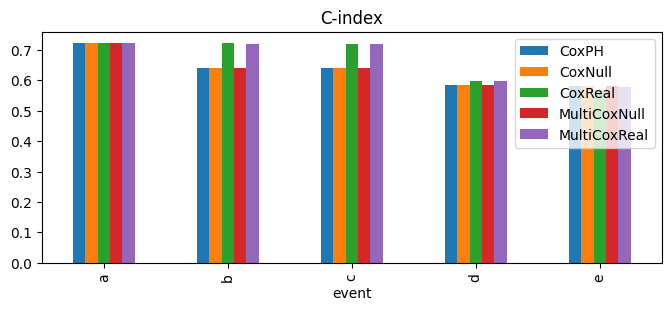

In [714]:
cindex_results.plot.bar(figsize = (8,3), title= "C-index")

In [650]:
np.round(cindex_results,4)

,CoxPH,CoxNull,CoxReal,MultiCoxNull,MultiCoxReal
event,,,,,
a,0.7230,0.7230,0.7228,0.7230,0.7216
b,0.6407,0.6407,0.7222,0.6407,0.7200
c,0.6417,0.6417,0.7186,0.6417,0.7205
d,0.5859,0.5859,0.5978,0.5859,0.5973
e,0.5807,0.5807,0.5694,0.5807,0.5791


In [718]:
print("*** Correlation in predictions for test set ***")
corr_results.T

*** Correlation in predictions for test set ***


event,a,b,c,d,e
CoxPH,1.000000,1.000000,1.000000,1.000000,1.000000
CoxNull,0.999997,1.000000,1.000000,1.000000,1.000000
CoxReal,0.999781,0.644445,0.617405,0.603384,0.810044
MultiCoxNull,1.000000,1.000000,1.000000,1.000000,1.000000
MultiCoxReal,0.995559,0.504240,0.640317,0.641310,0.692886


In [720]:
# Betas from MultiCox 
last = coxmmulti_null.net[-1]
with torch.no_grad():
        W = last.weight.detach().cpu().numpy()   # shape (K, p)
multi_betas = pd.DataFrame(W, index= ["a", "b", "c", "d", "e"], columns = covariate_cols).T
 # multi_betas

In [740]:
# Add betas and compare with the previous betas FROM single outcome
res["CoxMultiNull"] = np.nan
for e in ["a", "b", "c", "d", "e"]:
    res.loc[res.event == e, "CoxMultiNull"] = multi_betas[e]

res.loc["eth2", ["CoxPH", "CoxNN_null", "CoxMultiNull"]]

,CoxPH,CoxNN_null,CoxMultiNull
covariate,,,
eth2,2.011789,1.998820,2.011791
eth2,0.030950,0.030950,0.030951
eth2,0.010411,0.010406,0.010406
eth2,0.490595,0.490594,0.490594
eth2,0.567675,0.567663,0.567664


# Same in the binary format 

* In continuous time (Cox),  h_k(t | x) = h0_k(t) * exp(η_k(x))

* In discrete time, split follow-up into intervals (t0, t1], (t1, t2], …, (t_{J-1}, tJ]

* Then, model the conditional hazard per interval:  P(event in interval j | at risk at start of j, x) = h_{kj}(x)

* Using a logistic link: logit(h_{kj}(x)) = α_{kj} + η_k(x)

Step 2 — Neural binomial model (exact R analogue)

Here is the exact PyTorch equivalent of:

glm(event ~ bmi + age + hyp + sex + factor(interval), family="binomial")

## Set up 

In [726]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class DiscreteTimeLinear(nn.Module):
    def __init__(self, p, n_intervals):
        super().__init__()
        
        # Coefficients for continuous/binary predictors (bmi, age, hyp, sex)
        self.beta = nn.Linear(p, 1, bias=False)
        
        # Baseline hazard parameters for each interval (factor(interval))
        self.alpha = nn.Parameter(torch.zeros(n_intervals))
    
    def forward(self, x, interval_idx):
        # Linear combination of predictors
        eta = self.beta(x).squeeze()
        
        # Add interval-specific baseline hazard
        logit = eta + self.alpha[interval_idx]
        
        # Return logits (can apply sigmoid later for probabilities)
        return logit
    
    def predict_hazard(self, x, interval_idx):
        """Predict hazard probabilities"""
        return torch.sigmoid(self.forward(x, interval_idx))
    
    def predict_survival(self, x, intervals=None):
        """Predict survival probabilities for all intervals"""
        if intervals is None:
            intervals = range(len(self.alpha))
            
        # Calculate hazard for each interval
        hazards = []
        for i in intervals:
            # Create tensor of interval indices
            interval_tensor = torch.full((x.shape[0],), i, dtype=torch.long, device=x.device)
            hazards.append(self.predict_hazard(x, interval_tensor))
            
        hazards = torch.stack(hazards, dim=1)
        
        # Convert hazards to survival probabilities using product formula
        survival_probs = torch.cumprod(1 - hazards, dim=1)
        return survival_probs


In [728]:
# Example usage:
def train_model(model, X, interval_indices, events, lr=0.01, epochs=100):
    """
    Train the discrete time survival model
    
    Parameters:
    - X: tensor of covariates [n_samples, n_features]
    - interval_indices: tensor of interval indices [n_samples]
    - events: tensor of event indicators (0/1) [n_samples]
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        # Forward pass
        logits = model(X, interval_indices)
        
        # Binary cross-entropy loss (equivalent to binomial deviance)
        loss = F.binary_cross_entropy_with_logits(logits, events.float())
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 25 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')
    
    return model

In [730]:
# Function to prepare data for a specific event
def prepare_data_for_event(df, event_type, features,n_intervals=20):
    """
    Prepare data for training a discrete-time model for a specific event
    
    Parameters:
    - df: DataFrame with the data
    - event_type: 'a', 'b', 'c', 'd', or 'e'
    - features: list of feature columns to use
    
    Returns:
    - X: feature tensor
    - time_intervals: discretized time intervals
    - events: event indicators
    """
    # Extract relevant columns
    time_col = f'time_{event_type}'
    event_col = f'event_{event_type}'
    
    # Create feature matrix
    X = df[features].values
    
    # Discretize time into intervals (example: 10 intervals)
    max_time = df[time_col].max()
    interval_width = max_time / n_intervals
    time_intervals = np.floor(df[time_col] / interval_width).astype(int)
    time_intervals = np.clip(time_intervals, 0, n_intervals-1)  # Ensure within bounds
    
    # Get event indicators
    events = df[event_col].values
    
    return X, time_intervals, events, n_intervals


In [791]:
# Training function
def train_event_model(df, event_type, features, lr=0.005, epochs=100, batch_size=512,n_intervals=20):
    """Train a model for a specific event type"""
    
    # Prepare data
    X, time_intervals, events, n_intervals = prepare_data_for_event(df, event_type, features, n_intervals)
    # Convert to PyTorch tensors
    X_tensor = torch.FloatTensor(X)
    intervals_tensor = torch.LongTensor(time_intervals)
    events_tensor = torch.FloatTensor(events)
    # Initialize model
    model = DiscreteTimeLinear(len(features), n_intervals)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop
    n_samples = X_tensor.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    for epoch in range(epochs):
        total_loss = 0
        # Shuffle data
        indices = torch.randperm(n_samples)
        for i in range(n_batches):
            # Get batch
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, n_samples)
            batch_indices = indices[start_idx:end_idx]
            X_batch = X_tensor[batch_indices]
            intervals_batch = intervals_tensor[batch_indices]
            events_batch = events_tensor[batch_indices]
            
            # Forward pass
            logits = model(X_batch, intervals_batch)
            # Binary cross-entropy loss
            loss = F.binary_cross_entropy_with_logits(logits, events_batch)
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_indices)
        avg_loss = total_loss / n_samples
        if (epoch + 1) % 100 == 0:
            print(f'Event {event_type} - Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    return model

In [790]:
covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]

# Train models for each event 
binary_models = {}
for event_type in ['a', 'b', 'c', 'd', 'e']:
    print(f"\nTraining model for event {event_type}...")
    binary_models[event_type] = train_event_model(df_short, event_type, covariate_cols,n_intervals= 20, epochs = 1000)  


Training model for event a...
Event a - Epoch 50/1000, Loss: 0.0492
Event a - Epoch 100/1000, Loss: 0.0482
Event a - Epoch 150/1000, Loss: 0.0480
Event a - Epoch 200/1000, Loss: 0.0484
Event a - Epoch 250/1000, Loss: 0.0478
Event a - Epoch 300/1000, Loss: 0.0482
Event a - Epoch 350/1000, Loss: 0.0477
Event a - Epoch 400/1000, Loss: 0.0478
Event a - Epoch 450/1000, Loss: 0.0483
Event a - Epoch 500/1000, Loss: 0.0486
Event a - Epoch 550/1000, Loss: 0.0478
Event a - Epoch 600/1000, Loss: 0.0481
Event a - Epoch 650/1000, Loss: 0.0477
Event a - Epoch 700/1000, Loss: 0.0490
Event a - Epoch 750/1000, Loss: 0.0486
Event a - Epoch 800/1000, Loss: 0.0481
Event a - Epoch 850/1000, Loss: 0.0481
Event a - Epoch 900/1000, Loss: 0.0481
Event a - Epoch 950/1000, Loss: 0.0478
Event a - Epoch 1000/1000, Loss: 0.0476

Training model for event b...
Event b - Epoch 50/1000, Loss: 0.0519
Event b - Epoch 100/1000, Loss: 0.0499
Event b - Epoch 150/1000, Loss: 0.0493
Event b - Epoch 200/1000, Loss: 0.0495
Eve

In [794]:
# Put the binary coefficients into a dataframe to compare with previous coeffs from coxph
coef_binary = pd.DataFrame({e: binary_models[e].beta.weight.detach().numpy().flatten() for e in ["a", "b", "c", "d", "e"]})
coef_binary.index = covariate_cols
coef_binary

,a,b,c,d,e
age_start,0.013838,0.031546,0.024557,0.003344,0.001505
bmi,0.506646,-0.216099,-0.026746,0.167788,-0.121532
hyp,0.674165,0.691409,0.342340,-0.398488,-0.055455
smoke,-0.005046,-0.012685,0.395832,-0.470047,0.319769
sex,0.060015,0.114074,-0.006937,-0.136088,0.021367
eth1,0.522598,0.065532,-0.097622,0.590204,0.111566
eth2,2.265615,-0.411088,0.175221,0.171419,0.922959


In [796]:
# Add betas to "res" with the previous betas 
res["Binary"] = np.nan
for e in ["a", "b", "c", "d", "e"]:
    res.loc[res.event == e, "Binary"] = coef_binary[e]

<Axes: title={'center': 'eth2'}>

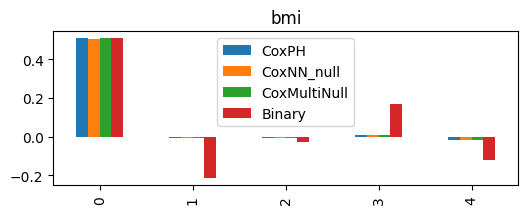

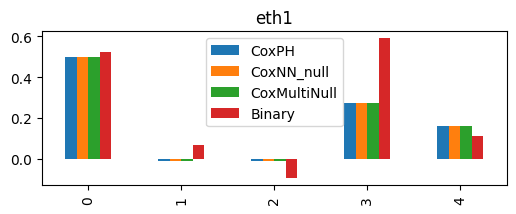

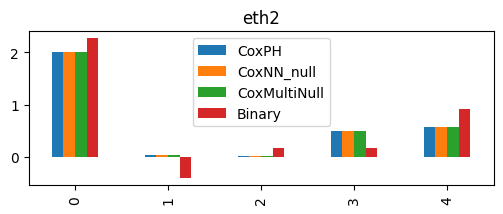

In [798]:
# plot them all
res.loc["bmi", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title= "bmi")
res.loc["eth1", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title= "eth1")
res.loc["eth2", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title ="eth2")

In [810]:
np.round(res.iloc[:, [0,2,6]],3)

,event,CoxPH,Binary
covariate,,,
age_start,a,0.026,0.014
bmi,a,0.507,0.507
hyp,a,0.696,0.674
smoke,a,-0.027,-0.005
sex,a,0.022,0.060
eth1,a,0.501,0.523
eth2,a,2.012,2.266
age_start,b,0.028,0.032
bmi,b,-0.005,-0.216
